In [ ]:
!pip install pretty_midi

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import pretty_midi
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import IPython.display as ipd

%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

bpm_df = pd.read_csv("processed/bpm_data.csv")
melody_df = pd.read_csv("processed/melody_dataset.csv")
drum_df = pd.read_csv("processed/drum_dataset.csv")
usable_df = pd.read_csv("processed/usable_songs.csv")

display(bpm_df.head())
display(melody_df.head())
display(drum_df.head())
display(usable_df.head())

,artist,song,bpm
0,ABC,Poison Arrow.mid,126.000126
1,ABC,4 Ever 2 Gether.mid,89.999955
2,ABC,"Look of Love, Part 1.mid",120.999944
3,Bronski Beat,Small Town Boy.mid,126.999985
4,Culture Club,Do You Really Want to Hurt Me.mid,104.000014


,artist,song,original_path,melody_path,instrument_program,instrument_name,track_name,n_notes,avg_pitch,bpm
0,ABC,4 Ever 2 Gether.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,75,Pan Flute,NaN,564,72.044326,89.999955
1,ABC,"Look of Love, Part 1.mid",/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,62,Synth Brass 1,Vocals,350,60.945714,120.999944
2,ABC,Poison Arrow.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,71,Clarinet,Melody & Lyric,339,61.218289,126.000126
3,Bronski Beat,Small Town Boy.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,73,Flute,Vocal,607,75.752883,126.999985
4,Culture Club,Church of the Poison Mind.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,61,Brass Section,NaN,75,72.920000,130.000130


,artist,song,original_path,drum_path,n_drum_tracks_merged,n_notes,n_unique_drums,bpm,duration
0,ABC,4 Ever 2 Gether.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,1,3214,13,89.999955,207.430659
1,ABC,"Look of Love, Part 1.mid",/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,1,1714,14,120.999944,208.128196
2,ABC,Poison Arrow.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,1,2263,15,126.000126,202.936305
3,Bronski Beat,Small Town Boy.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,1,2931,9,126.999985,310.551688
4,Culture Club,Church of the Poison Mind.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,2,2533,7,130.000130,238.109137


,artist,song,bpm,has_drums,n_drum_notes,n_total_tracks,filepath
0,ABC,4 Ever 2 Gether.mid,89.999955,True,3214,11,/Users/donghyunhahn/Desktop/spring 2026/cse 15...
1,ABC,"Look of Love, Part 1.mid",120.999944,True,1714,16,/Users/donghyunhahn/Desktop/spring 2026/cse 15...
2,ABC,Poison Arrow.mid,126.000126,True,2263,14,/Users/donghyunhahn/Desktop/spring 2026/cse 15...
3,Bronski Beat,Small Town Boy.mid,126.999985,True,2931,12,/Users/donghyunhahn/Desktop/spring 2026/cse 15...
4,Culture Club,Church of the Poison Mind.mid,130.000130,True,2533,14,/Users/donghyunhahn/Desktop/spring 2026/cse 15...


## Helper Functions and Symbolic Representation Utilities

This section defines the core constants and helper functions used throughout the symbolic synth-pop preprocessing pipeline.

These utilities are responsible for:

```text
1. Defining symbolic music representations
2. Converting MIDI notes into discrete time grids
3. Extracting BPM information
4. Mapping drum MIDI pitches into simplified drum classes

In [3]:
STEPS_PER_BAR = 16
BARS_PER_SEGMENT = 4
TOTAL_STEPS = STEPS_PER_BAR * BARS_PER_SEGMENT
REST_TOKEN = 0

DRUM_MAP = {
    36: 0, 35: 0,  # kick
    38: 1, 40: 1,  # snare
    42: 2, 44: 2, 46: 2  # hi-hat
}

def get_first_bpm(midi_path, fallback=120):
    pm = pretty_midi.PrettyMIDI(midi_path)
    _, tempi = pm.get_tempo_changes()
    if len(tempi) == 0:
        return fallback
    return float(tempi[0])

def step_sec_from_bpm(bpm):
    return (60.0 / bpm) / 4

def pitch_notes_to_grid(notes, start_time, step_sec, num_steps):
    grid = np.zeros(num_steps, dtype=np.int64)

    for note in notes:
        step = int(round((note.start - start_time) / step_sec))
        if 0 <= step < num_steps:
            grid[step] = note.pitch + 1

    return grid

def drum_notes_to_grid(notes, start_time, step_sec, num_steps):
    grid = np.zeros((num_steps, 3), dtype=np.int64)

    for note in notes:
        step = int(round((note.start - start_time) / step_sec))
        if 0 <= step < num_steps and note.pitch in DRUM_MAP:
            grid[step, DRUM_MAP[note.pitch]] = 1

    return grid

## MIDI Segment Extraction

The function `midi_pair_to_segments()` is responsible for converting raw MIDI files into usable training samples for the conditional drum generation model.

Each song is represented using:

- Melody MIDI track
- Drum MIDI track
- BPM information

The preprocessing pipeline works as follows:

### 1. Load MIDI Files

The melody and drum MIDI files are loaded using `pretty_midi`.

```python
melody_pm = pretty_midi.PrettyMIDI(melody_path)
drum_pm = pretty_midi.PrettyMIDI(drum_path)

In [4]:
def midi_pair_to_segments(melody_path, drum_path, bpm=None, min_melody_notes=8, min_drum_hits=8):
    melody_pm = pretty_midi.PrettyMIDI(melody_path)
    drum_pm = pretty_midi.PrettyMIDI(drum_path)

    if bpm is None:
        bpm = get_first_bpm(melody_path)

    step_sec = step_sec_from_bpm(bpm)
    segment_sec = step_sec * TOTAL_STEPS

    melody_notes = []
    for inst in melody_pm.instruments:
        melody_notes.extend(inst.notes)

    drum_notes = []
    for inst in drum_pm.instruments:
        drum_notes.extend(inst.notes)

    end_time = max(melody_pm.get_end_time(), drum_pm.get_end_time())

    segments = []

    start_time = 0.0
    while start_time + segment_sec <= end_time:
        melody_grid = pitch_notes_to_grid(
            melody_notes, start_time, step_sec, TOTAL_STEPS
        )

        drum_grid = drum_notes_to_grid(
            drum_notes, start_time, step_sec, TOTAL_STEPS
        )

        if np.count_nonzero(melody_grid) >= min_melody_notes and drum_grid.sum() >= min_drum_hits:
            segments.append({
                "melody": melody_grid,
                "drums": drum_grid,
                "bpm": bpm,
                "start_time": start_time
            })

        start_time += segment_sec

    return segments

## Final Dataset Construction

After extracting usable 4-bar segments from each MIDI pair, all samples are collected into unified NumPy arrays for model training.

The preprocessing loop iterates through every matched melody/drum MIDI pair:

```python
for fname in matched_files:

In [5]:
all_melodies = []
all_drums = []
all_bpms = []
all_files = []
all_start_times = []

melody_files = set(os.listdir("processed/melodies_all"))
drum_files = set(os.listdir("processed/drums_all"))

matched_files = sorted(list(melody_files & drum_files))

for fname in matched_files:
    melody_path = os.path.join("processed/melodies_all", fname)
    drum_path = os.path.join("processed/drums_all", fname)

    try:
        segments = midi_pair_to_segments(
            melody_path,
            drum_path,
            min_melody_notes=8,
            min_drum_hits=8
        )

        for seg in segments:
            all_melodies.append(seg["melody"])
            all_drums.append(seg["drums"])
            all_bpms.append(seg["bpm"])
            all_files.append(fname)
            all_start_times.append(seg["start_time"])

    except Exception as e:
        print("Skipping", fname, "because", e)

all_melodies = np.array(all_melodies)
all_drums = np.array(all_drums)
all_bpms = np.array(all_bpms)

print("melodies:", all_melodies.shape)
print("drums:", all_drums.shape)
print("bpms:", all_bpms.shape)
print("num samples:", len(all_melodies))

melodies: (4882, 64)
drums: (4882, 64, 3)
bpms: (4882,)
num samples: 4882


## Saving the Final Training Dataset

After preprocessing all MIDI files and extracting usable 4-bar segments, the complete dataset is saved into a compressed NumPy archive (`.npz` file).

```python
np.savez(
    "processed/task2_drum_dataset_4bar.npz",
    melodies=all_melodies,
    drums=all_drums,
    bpms=all_bpms,
    files=np.array(all_files),
    start_times=np.array(all_start_times)
)

In [6]:
np.savez(
    "processed/task2_drum_dataset_4bar.npz",
    melodies=all_melodies,
    drums=all_drums,
    bpms=all_bpms,
    files=np.array(all_files),
    start_times=np.array(all_start_times)
)

## Dataset Source

The dataset is built on the **Lakh MIDI Dataset (LMD)** (Raffel, 2016), a large-scale
collection of ~176,000 MIDI files aligned to the Million Song Dataset.

From this corpus, a synth-pop subset was curated by filtering tracks from representative
80s artists including **Depeche Mode, Culture Club, ABC, Bronski Beat**, and others.

For each song, two tracks were automatically extracted:
- **Melody**: selected by scoring instruments on pitch range, note density, and monophony
- **Drum**: identified via MIDI channel 9 (`is_drum=True`), merged if multiple tracks existed

Only songs containing both a valid melody and drum track were retained.

### Dataset Statistics
```text
Matched songs:    ~70–90 synth-pop tracks
4-bar segments:   4,882 total
BPM range:        ~90–130 BPM
Segment length:   64 steps (16 steps/bar × 4 bars)
Drum classes:     kick (MIDI 35/36), snare (38/40), hi-hat (42/44/46)

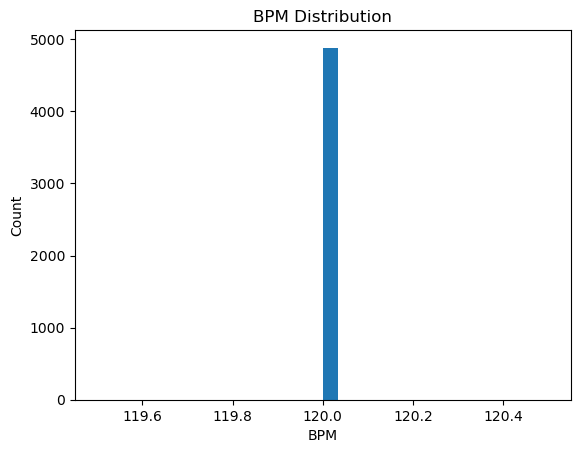

In [7]:

plt.hist(all_bpms, bins=30)
plt.title("BPM Distribution")
plt.xlabel("BPM")
plt.ylabel("Count")
plt.show()

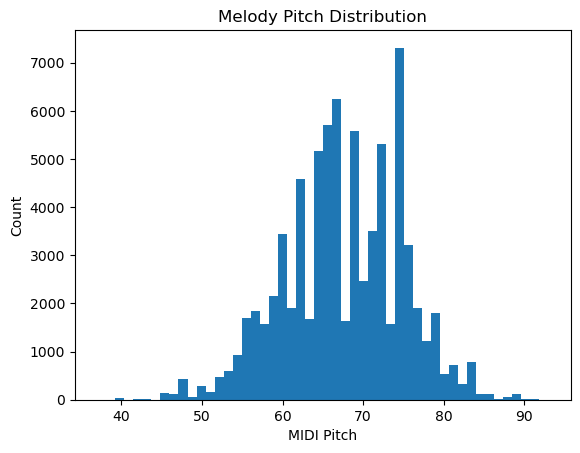

In [8]:
all_pitches = all_melodies.flatten()
all_pitches = all_pitches[all_pitches > 0] - 1

plt.hist(all_pitches, bins=50)
plt.title("Melody Pitch Distribution")
plt.xlabel("MIDI Pitch")
plt.ylabel("Count")
plt.show()

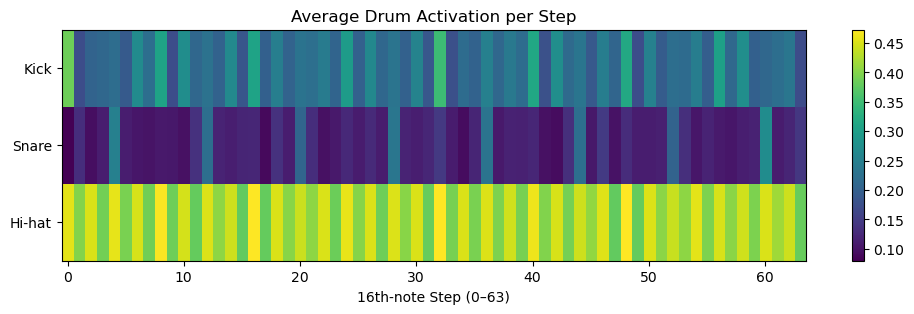

In [28]:
avg_drum = all_drums.mean(axis=0).T   # shape: (3, 64)
plt.figure(figsize=(12, 3))
plt.imshow(avg_drum, aspect='auto')
plt.yticks([0, 1, 2], ["Kick", "Snare", "Hi-hat"])
plt.xlabel("16th-note Step (0–63)")
plt.title("Average Drum Activation per Step")
plt.colorbar()
plt.show()

# Converting MIDI Files into 16-Step Grid Representations

## Goal

The purpose of this preprocessing step is to convert raw MIDI files into a structured symbolic representation that can be used for machine learning models such as LSTMs or Transformers.

Our Task 2 objective is:

> Given a base melody line and BPM, generate an 80s synth-pop style accompaniment consisting of basslines and drum grooves.

To achieve this, we first transform MIDI tracks into fixed-size 16-step grids.

---

# Why Use a 16-Step Grid?

Most 80s synth-pop music follows a regular 4/4 rhythmic structure with repetitive drum machine patterns and looping basslines.

A 16-step grid divides one bar into 16 equal subdivisions:

```text
1 e & a 2 e & a 3 e & a 4 e & a

In [10]:
import pretty_midi
import numpy as np

STEPS_PER_BAR = 16
BARS_PER_SEGMENT = 4
STEPS_PER_SEGMENT = STEPS_PER_BAR * BARS_PER_SEGMENT

DRUM_MAP = {
    36: 0,  # Kick
    38: 1,  # Snare
    40: 1,  # Snare
    42: 2,  # Closed Hi-Hat
    44: 2,  # Pedal Hi-Hat
    46: 2,  # Open Hi-Hat
}

def get_bpm(pm):
    tempo_changes, tempi = pm.get_tempo_changes()
    if len(tempi) == 0:
        return 120
    return float(tempi[0])

def step_duration_seconds(bpm):
    beats_per_bar = 4
    seconds_per_beat = 60.0 / bpm
    return seconds_per_beat / 4  # 16th note

def instrument_name(inst):
    return (inst.name or "").lower()

def is_drum_track(inst):
    return inst.is_drum

def is_bass_track(inst):
    name = instrument_name(inst)
    return "bass" in name or (32 <= inst.program <= 39 and not inst.is_drum)

def is_melody_track(inst):
    name = instrument_name(inst)
    bad_words = ["bass", "drum", "perc", "pad", "chord"]
    return not inst.is_drum and not any(w in name for w in bad_words)

def notes_to_pitch_grid(notes, start_time, step_sec, num_steps):
    """
    Converts MIDI notes into a pitch grid 

    Representation:
    0 = Rest
    1 ~ 128 = actual MIDI pitch 0 ~ 127 shifted by + 1 
    """
    grid = np.zeros(num_steps, dtype=np.int64)

    for note in notes:
        step = int(round((note.start - start_time) / step_sec))

        if 0 <= step < num_steps:
            grid[step] = note.pitch + 1

    return grid

def drums_to_grid(notes, start_time, step_sec, num_steps):
    grid = np.zeros((num_steps, 3), dtype=np.float32)

    for note in notes:
        step = int(round((note.start - start_time) / step_sec))
        if 0 <= step < num_steps and note.pitch in DRUM_MAP:
            drum_idx = DRUM_MAP[note.pitch]
            grid[step, drum_idx] = 1.0

    return grid

def midi_to_4bar_segments(midi_path):
    pm = pretty_midi.PrettyMIDI(midi_path)
    bpm = get_bpm(pm)
    step_sec = step_duration_seconds(bpm)
    segment_sec = step_sec * STEPS_PER_SEGMENT

    melody_instruments = [i for i in pm.instruments if is_melody_track(i)]
    bass_instruments = [i for i in pm.instruments if is_bass_track(i)]
    drum_instruments = [i for i in pm.instruments if is_drum_track(i)]

    if not melody_instruments or not bass_instruments or not drum_instruments:
        return []

    melody_notes = melody_instruments[0].notes
    bass_notes = bass_instruments[0].notes
    drum_notes = drum_instruments[0].notes

    end_time = pm.get_end_time()
    segments = []

    start = 0.0
    while start + segment_sec <= end_time:
        melody_grid = notes_to_pitch_grid(
            melody_notes, start, step_sec, STEPS_PER_SEGMENT
        )
        bass_grid = notes_to_pitch_grid(
            bass_notes, start, step_sec, STEPS_PER_SEGMENT
        )
        drum_grid = drums_to_grid(
            drum_notes, start, step_sec, STEPS_PER_SEGMENT
        )

        if melody_grid.sum() > 0 and bass_grid.sum() > 0 and drum_grid.sum() > 0:
            segments.append({
                "bpm": bpm,
                "melody": melody_grid,
                "bass": bass_grid,
                "drums": drum_grid
            })

        start += segment_sec

    return segments

## Rule-Based Synth-Pop Baseline Generator

Before training the LSTM model, a rule-based accompaniment system was implemented as a baseline comparison model.

The purpose of this baseline is to generate simple synth-pop style basslines and drum grooves using handcrafted musical rules instead of machine learning.

This allows comparison between:

```text id="fjlwm1"
1. Rule-based accompaniment
2. LSTM-generated accompaniment

In [11]:
import pretty_midi
import numpy as np

STEPS_PER_BAR = 16
BARS = 4
TOTAL_STEPS = STEPS_PER_BAR * BARS
REST_TOKEN = 0

DRUM_PITCHES = {
    "kick": 36,
    "snare": 38,
    "closed_hat": 42,
    "open_hat": 46,
}

def step_sec_from_bpm(bpm):
    return (60.0 / bpm) / 4  # 16th note

def estimate_root_from_melody(melody_grid):
    pitch_tokens = [p for p in melody_grid if p > REST_TOKEN]

    if len(pitch_tokens) == 0:
        return 48  # actual MIDI pitch C3 fallback

    actual_pitches = [p - 1 for p in pitch_tokens]
    pitch_classes = [p % 12 for p in actual_pitches]
    root_pc = max(set(pitch_classes), key=pitch_classes.count)

    return 36 + root_pc  # actual MIDI pitch around C2-B2


def generate_rule_based_bass(melody_grid):
    root_actual = estimate_root_from_melody(melody_grid)
    fifth_actual = root_actual + 7
    octave_actual = root_actual + 12

    root = root_actual + 1
    fifth = fifth_actual + 1
    octave = octave_actual + 1

    bass_grid = np.zeros(TOTAL_STEPS, dtype=np.int64)

    pattern = [
        root, 0, root, 0,
        fifth, 0, root, 0,
        octave, 0, fifth, 0,
        root, 0, fifth, 0,
    ]

    for bar in range(BARS):
        start = bar * STEPS_PER_BAR
        bass_grid[start:start + STEPS_PER_BAR] = pattern

    return bass_grid

def generate_rule_based_drums():
    drum_grid = np.zeros((TOTAL_STEPS, 3), dtype=np.int64)

    for step in range(TOTAL_STEPS):
        pos = step % STEPS_PER_BAR

        # Hi-hat on every 8th note
        if pos % 2 == 0:
            drum_grid[step, 2] = 1

        # Kick on beats 1 and 3
        if pos in [0, 8]:
            drum_grid[step, 0] = 1

        # Snare on beats 2 and 4
        if pos in [4, 12]:
            drum_grid[step, 1] = 1

        # Small 80s-style extra kick before beat 4
        if pos == 10:
            drum_grid[step, 0] = 1

    return drum_grid

def add_pitch_grid_to_instrument(instrument, pitch_grid, bpm, velocity=90):
    step_sec = step_sec_from_bpm(bpm)

    for step, pitch_token in enumerate(pitch_grid):
        if pitch_token == REST_TOKEN:
            continue

        actual_pitch = int(pitch_token) - 1

        start = step * step_sec
        end = start + step_sec * 0.9

        note = pretty_midi.Note(
            velocity=velocity,
            pitch=actual_pitch,
            start=start,
            end=end
        )

        instrument.notes.append(note)
        
def add_drum_grid_to_instrument(instrument, drum_grid, bpm):
    step_sec = step_sec_from_bpm(bpm)

    for step in range(drum_grid.shape[0]):
        start = step * step_sec
        end = start + step_sec * 0.5

        kick, snare, hat = drum_grid[step]

        if kick:
            instrument.notes.append(pretty_midi.Note(
                velocity=110,
                pitch=DRUM_PITCHES["kick"],
                start=start,
                end=end
            ))

        if snare:
            instrument.notes.append(pretty_midi.Note(
                velocity=100,
                pitch=DRUM_PITCHES["snare"],
                start=start,
                end=end
            ))

        if hat:
            instrument.notes.append(pretty_midi.Note(
                velocity=75,
                pitch=DRUM_PITCHES["closed_hat"],
                start=start,
                end=end
            ))

def create_rule_based_synthpop_midi(melody_grid, bpm=120, output_path="rule_based_synthpop.mid"):
    pm = pretty_midi.PrettyMIDI(initial_tempo=bpm)

    melody_inst = pretty_midi.Instrument(program=80, name="Melody Synth Lead")
    bass_inst = pretty_midi.Instrument(program=38, name="Generated Synth Bass")
    drum_inst = pretty_midi.Instrument(program=0, is_drum=True, name="Drum Machine")

    bass_grid = generate_rule_based_bass(melody_grid)
    drum_grid = generate_rule_based_drums()

    add_pitch_grid_to_instrument(melody_inst, melody_grid, bpm, velocity=95)
    add_pitch_grid_to_instrument(bass_inst, bass_grid, bpm, velocity=90)
    add_drum_grid_to_instrument(drum_inst, drum_grid, bpm)

    pm.instruments.append(melody_inst)
    pm.instruments.append(bass_inst)
    pm.instruments.append(drum_inst)

    pm.write(output_path)

    return bass_grid, drum_grid

melody_grid = np.zeros(64, dtype=np.int64)

# simple sample melody
melody_grid[0] = 60
melody_grid[4] = 64
melody_grid[8] = 67
melody_grid[12] = 72

melody_grid[16] = 72
melody_grid[20] = 67
melody_grid[24] = 64
melody_grid[28] = 60

bass_grid, drum_grid = create_rule_based_synthpop_midi(
    melody_grid=melody_grid,
    bpm=120,
    output_path="rule_based_synthpop.mid"
)

In [12]:
melody_grid = np.zeros(64, dtype=np.int64)

# simple sample melody
melody_grid[0] = 60
melody_grid[4] = 64
melody_grid[8] = 67
melody_grid[12] = 72

melody_grid[16] = 72
melody_grid[20] = 67
melody_grid[24] = 64
melody_grid[28] = 60

bass_grid, drum_grid = create_rule_based_synthpop_midi(
    melody_grid=melody_grid,
    bpm=120,
    output_path="rule_based_synthpop.mid"
)

In [13]:
ipd.display(ipd.Audio("rule_based_synthpop.mid"))

## Rule-based vs LSTM: Comparison

| | Rule-based | ConditionalDrumLSTM |
|---|---|---|
| Training required | No | Yes (30 epochs) |
| Melody-aware | Partial (root pitch only) | Yes (full sequence) |
| Output diversity | None (always identical) | High (stochastic mode) |
| Beat regularity | Perfect (hardcoded) | Lower (learned from data) |
| Hit rate accuracy (MAE) | 0.0406 | **0.0091** (4.5x better) |
| Handles syncopation | No | Yes |
| Interpretable | Yes | No (black box) |

The rule-based model guarantees rhythmic regularity but produces the same output
regardless of the melody. The LSTM trades some regularity for a significantly more
accurate hit rate distribution and melody-dependent pattern generation.


# Conditional LSTM for Drum Groove Generation

## Goal

In Task 2, we build a conditional symbolic generation model.

The model receives:

- a base melody line
- BPM information

and predicts:

- a drum groove sequence

This allows us to generate an 80s synth-pop style drum accompaniment from a given melody.

The bassline is not learned by the LSTM in the current version. Instead, it is generated separately using a rule-based bass generator based on the estimated root of the melody.

class DrumDataset(Dataset):
    def __init__(self, melody_grids, bpm_values, drum_grids):
        """
        melody_grids: shape (N, 64)
        bpm_values: shape (N,)
        drum_grids: shape (N, 64, 3)
        """

        self.melody_grids = torch.LongTensor(melody_grids)
        self.bpm_values = torch.FloatTensor(bpm_values)
        self.drum_grids = torch.FloatTensor(drum_grids)

    def __len__(self):
        return len(self.melody_grids)

    def __getitem__(self, idx):

        melody = self.melody_grids[idx]
        bpm = self.bpm_values[idx]
        drums = self.drum_grids[idx]

        # normalize bpm
        bpm_norm = (bpm - 120.0) / 40.0

        return melody, bpm_norm, drums

In [14]:
class DrumDataset(Dataset):
    def __init__(self, melody_grids, bpm_values, drum_grids):
        """
        melody_grids: shape (N, 64)
        bpm_values: shape (N,)
        drum_grids: shape (N, 64, 3)
        """

        self.melody_grids = torch.LongTensor(melody_grids)
        self.bpm_values = torch.FloatTensor(bpm_values)
        self.drum_grids = torch.FloatTensor(drum_grids)

    def __len__(self):
        return len(self.melody_grids)

    def __getitem__(self, idx):

        melody = self.melody_grids[idx]
        bpm = self.bpm_values[idx]
        drums = self.drum_grids[idx]

        # normalize bpm
        bpm_norm = (bpm - 120.0) / 40.0

        return melody, bpm_norm, drums

## Conditional LSTM Architecture

The `ConditionalDrumLSTM` model is a conditional sequence generation model designed to generate synth-pop drum grooves from:

```text id="1q6wef"
Input:
melody sequence + BPM

Output: 
drum groove sequence

In [15]:
import torch.nn as nn

class ConditionalDrumLSTM(nn.Module):
    def __init__(
        self,
        melody_vocab_size=129,
        melody_emb_dim=32,
        hidden_dim=128,
        num_layers=2,
        drum_dim=3,
        dropout=0.2
    ):
        super().__init__()

        self.melody_embedding = nn.Embedding(
            num_embeddings=melody_vocab_size,
            embedding_dim=melody_emb_dim,
            padding_idx=REST_TOKEN
        )

        self.lstm = nn.LSTM(
            input_size=melody_emb_dim + 1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.drum_head = nn.Linear(hidden_dim, drum_dim)

    def forward(self, melody, bpm):

        batch_size, seq_len = melody.shape

        melody_emb = self.melody_embedding(melody)

        bpm_feature = bpm.view(batch_size, 1, 1)
        bpm_feature = bpm_feature.repeat(1, seq_len, 1)

        x = torch.cat([melody_emb, bpm_feature], dim=-1)

        lstm_out, _ = self.lstm(x)

        drum_logits = self.drum_head(lstm_out)

        return drum_logits

## Why LSTM over Transformer?

An LSTM was chosen over a Transformer architecture for three reasons:

1. **Sequence length**: At 64 steps, sequences are short enough that LSTMs handle
   them well without the memory issues or positional encoding complexity of Transformers.

2. **Dataset size**: With ~4,882 training segments, a Transformer's self-attention
   would likely overfit. LSTMs generalize better on smaller datasets.

3. **Simplicity**: The LSTM is easier to interpret and debug, making it a more
   appropriate baseline for this task.

A Transformer encoder-decoder with cross-attention between melody and drum sequences
would be a natural extension given more data.


## LSTM Training Procedure

The function `train_conditional_drum_lstm()` trains the conditional LSTM model to generate drum grooves from melody sequences and BPM information.

The training objective is:

```text id="p5ijc9"
Input:
melody + BPM

Target:
drum groove

In [16]:
def train_conditional_drum_lstm(
    model,
    train_loader,
    pos_weight,
    num_epochs=20,
    lr=0.001,
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    model = model.to(device)

    pos_weight_tensor = torch.FloatTensor(pos_weight).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for melody, bpm, drums in train_loader:
            melody = melody.to(device)
            bpm = bpm.to(device)
            drums = drums.to(device)

            optimizer.zero_grad()

            drum_logits = model(melody, bpm)

            loss = criterion(drum_logits, drums)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    return model

## Drum Groove Generation

After training the conditional LSTM model, new drum grooves can be generated from:

```text
Input:
melody + BPM

### 1. Deterministic Generation
Uses class-specific thresholds for kick, snare, and hi-hat prediction.

Advantages:
- stable and reproducible output
- prevents hi-hat collapse
- easier evaluation

Limitation:
- same melody always produces the same groove


In [17]:
def generate_drums(
    model,
    melody_grid,
    bpm,
    thresholds=np.array([0.45, 0.38, 0.50]),
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    model.eval()
    model = model.to(device)

    melody = torch.LongTensor(melody_grid).unsqueeze(0).to(device)

    bpm_norm = torch.FloatTensor(
        [(bpm - 120.0) / 40.0]
    ).to(device)

    with torch.no_grad():

        drum_logits = model(melody, bpm_norm)

        drum_probs = torch.sigmoid(
            drum_logits
        ).squeeze(0).cpu().numpy()

    thresholds = np.array(thresholds).reshape(1, 3)

    drum_pred = (
        drum_probs > thresholds
    ).astype(np.int64)

    return drum_pred

### 2. Stochastic Generation
Samples drum hits probabilistically from model output probabilities.

Advantages:
- generates multiple groove variations
- more human-like rhythmic diversity
- less repetitive

Limitation:
- output may occasionally become noisy or unstable

Temperature sampling was additionally used to control generation randomness.

In [18]:
def generate_drums_stochastic(
    model,
    melody_grid,
    bpm,
    temperature=1.0,
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    model.eval()
    model = model.to(device)

    melody = torch.LongTensor(melody_grid).unsqueeze(0).to(device)
    bpm_norm = torch.FloatTensor([(bpm - 120.0) / 40.0]).to(device)

    with torch.no_grad():
        logits = model(melody, bpm_norm)
        logits = logits / temperature
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()

    sampled = np.random.binomial(1, probs).astype(np.int64)

    return sampled

## Final MIDI Reconstruction from LSTM Drum Generation

After generating drum patterns using the trained conditional LSTM model, the predicted symbolic drum sequence is converted back into a playable MIDI arrangement.

The function:

```python
create_lstm_midi(...)

In [19]:
# MIDI from LSTM drum generation

def create_lstm_midi(
    melody_grid,
    drum_pred,
    bpm=120,
    output_path="lstm_output.mid"
):
    pm = pretty_midi.PrettyMIDI(initial_tempo=bpm)

    melody_inst = pretty_midi.Instrument(
        program=80,
        name="Melody Synth Lead"
    )

    bass_inst = pretty_midi.Instrument(
        program=38,
        name="Rule-Based Synth Bass"
    )

    drum_inst = pretty_midi.Instrument(
        program=0,
        is_drum=True,
        name="LSTM Drums"
    )

    # generate rule-based bass
    bass_grid = generate_rule_based_bass(melody_grid)

    # add melody
    add_pitch_grid_to_instrument(
        melody_inst,
        melody_grid,
        bpm
    )

    # add bass
    add_pitch_grid_to_instrument(
        bass_inst,
        bass_grid,
        bpm
    )

    # add drums
    add_drum_grid_to_instrument(
        drum_inst,
        drum_pred,
        bpm
    )

    pm.instruments.append(melody_inst)
    pm.instruments.append(bass_inst)
    pm.instruments.append(drum_inst)

    pm.write(output_path)

    return bass_grid

## Train / Validation Dataset Split

Before training the conditional LSTM model, the dataset is divided into:

```text
1. Training Set
2. Validation Set

In [20]:
from sklearn.model_selection import train_test_split

data = np.load(
    "processed/task2_drum_dataset_4bar.npz",
    allow_pickle=True
)

X_melody = data["melodies"]
X_bpm = data["bpms"]
Y_drums = data["drums"]

(
    melody_train,
    melody_val,
    bpm_train,
    bpm_val,
    drums_train,
    drums_val
) = train_test_split(
    X_melody,
    X_bpm,
    Y_drums,
    test_size=0.1,
    random_state=42
)

print(melody_train.shape)
print(drums_train.shape)

(4393, 64)
(4393, 64, 3)


In [21]:
# drums_train shape: (N, 64, 3)
positive_counts = drums_train.sum(axis=(0, 1))
total_counts = drums_train.shape[0] * drums_train.shape[1]
negative_counts = total_counts - positive_counts

pos_weight = np.sqrt(negative_counts / (positive_counts + 1e-8))

print("positive counts:", positive_counts)
print("pos_weight:", pos_weight)

positive counts: [ 64751  36172 119354]
pos_weight: [1.82812712 2.60242998 1.16430855]


## End-to-End Conditional Drum Generation Pipeline

This section combines all previous components into the complete symbolic synth-pop generation pipeline.

The pipeline performs:

```text
Preprocessed Dataset
        ↓
PyTorch Dataset / DataLoader
        ↓
Conditional LSTM Training
        ↓
Drum Groove Generation
        ↓
MIDI Reconstruction
        ↓
Final Synth-Pop MIDI Output

In [22]:
# 1. Load preprocessed dataset
data = np.load("processed/task2_drum_dataset_4bar.npz", allow_pickle=True)

X_melody = data["melodies"]
X_bpm = data["bpms"]
Y_drums = data["drums"]

# 2. Dataset / DataLoader
train_dataset = DrumDataset(melody_train, bpm_train, drums_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 3. Train drum-only LSTM
model = ConditionalDrumLSTM()

model = train_conditional_drum_lstm(
    model,
    train_loader,
    pos_weight=pos_weight,
    num_epochs=30,
    lr=0.001
)

# 4. Generate drums from melody + bpm
sample_melody = X_melody[17]
sample_bpm = float(X_bpm[17])

# 4 -1 deterministic
drum_pred_det = generate_drums(
    model,
    sample_melody,
    sample_bpm
)

# 5. Save MIDI
create_lstm_midi(
    melody_grid=sample_melody,
    drum_pred=drum_pred_det,
    bpm=sample_bpm,
    output_path="lstm_deterministic.mid"
)

# 4 - 2 stochastic 
drum_pred_stoch = generate_drums_stochastic(
    model,
    sample_melody,
    sample_bpm,
    temperature=1.0
)

# 5. Save MIDI
create_lstm_midi(
    melody_grid=sample_melody,
    drum_pred=drum_pred_stoch,
    bpm=sample_bpm,
    output_path="lstm_stochastic.mid"
)


Epoch 1/30, Loss: 0.7430
Epoch 2/30, Loss: 0.7095
Epoch 3/30, Loss: 0.7047
Epoch 4/30, Loss: 0.6994
Epoch 5/30, Loss: 0.6931
Epoch 6/30, Loss: 0.6853
Epoch 7/30, Loss: 0.6759
Epoch 8/30, Loss: 0.6672
Epoch 9/30, Loss: 0.6586
Epoch 10/30, Loss: 0.6490
Epoch 11/30, Loss: 0.6383
Epoch 12/30, Loss: 0.6286
Epoch 13/30, Loss: 0.6211
Epoch 14/30, Loss: 0.6142
Epoch 15/30, Loss: 0.6064
Epoch 16/30, Loss: 0.6053
Epoch 17/30, Loss: 0.5918
Epoch 18/30, Loss: 0.5828
Epoch 19/30, Loss: 0.5784
Epoch 20/30, Loss: 0.5744
Epoch 21/30, Loss: 0.5653
Epoch 22/30, Loss: 0.5602
Epoch 23/30, Loss: 0.5509
Epoch 24/30, Loss: 0.5459
Epoch 25/30, Loss: 0.5464
Epoch 26/30, Loss: 0.5321
Epoch 27/30, Loss: 0.5336
Epoch 28/30, Loss: 0.5264
Epoch 29/30, Loss: 0.5195
Epoch 30/30, Loss: 0.5142


array([37,  0, 37,  0, 44,  0, 37,  0, 49,  0, 44,  0, 37,  0, 44,  0, 37,
        0, 37,  0, 44,  0, 37,  0, 49,  0, 44,  0, 37,  0, 44,  0, 37,  0,
       37,  0, 44,  0, 37,  0, 49,  0, 44,  0, 37,  0, 44,  0, 37,  0, 37,
        0, 44,  0, 37,  0, 49,  0, 44,  0, 37,  0, 44,  0], dtype=int64)

In [27]:
# Side-by-side audio comparison: rule-based vs LSTM deterministic vs LSTM stochastic
print("Rule-based baseline:")
ipd.display(ipd.Audio("rule_based_synthpop.mid"))

print("LSTM (deterministic):")
ipd.display(ipd.Audio("lstm_deterministic.mid"))

print("LSTM (stochastic, temperature=1.0):")
ipd.display(ipd.Audio("lstm_stochastic.mid"))


Rule-based baseline:


LSTM (deterministic):


LSTM (stochastic, temperature=1.0):


## Evaluation Metrics

To evaluate the generated drum patterns, four different analyses were performed.

### 1. Drum Hit Rate Comparison
Compares the average kick, snare, and hi-hat activation frequency between:

- real dataset
- rule-based baseline
- deterministic LSTM generation
- stochastic LSTM generation

This measures whether the generated rhythms statistically resemble real synth-pop drum patterns.

---

### 2. MAE from Real Drum Distribution
Mean Absolute Error (MAE) is used to measure how far each generation method deviates from the real dataset drum distribution.

Lower MAE indicates that the generated drum density is closer to real music data.

---

### 3. Stochastic Diversity Analysis
The same melody input is generated multiple times using stochastic sampling.

This evaluates whether the model can produce multiple rhythmic variations instead of generating the exact same groove every time.

---

### 4. Beat Alignment Score
Measures how often generated drum hits occur on musically expected beat positions commonly found in 80s synth-pop rhythms.

Examples:
- kick on beats 1 and 3
- snare on beats 2 and 4
- hi-hat on regular 8th-note positions

Higher alignment scores indicate more rhythmically structured drum generation.

In [23]:
import numpy as np

N_SAMPLES   = 50
THRESHOLDS  = np.array([0.45, 0.38, 0.50])

# 1. Ground truth hit rates from training data
real_hit_rates = drums_train.mean(axis=(0, 1))   # shape: (3,) — [kick, snare, hat]
real_per_bar   = real_hit_rates * 16              # convert to hits per bar (16 steps)

# 2. Rule-based baseline — melody-independent, always the same pattern
rule_drum_grid = generate_rule_based_drums()      # shape: (64, 3)
rule_hit_rates = rule_drum_grid.mean(axis=0)
rule_per_bar   = rule_hit_rates * 16

# 3. LSTM deterministic — threshold-based binary decision
det_preds = []
for idx in range(N_SAMPLES):
    pred = generate_drums(model, X_melody[idx], float(X_bpm[idx]), thresholds=THRESHOLDS)
    det_preds.append(pred)
det_preds   = np.array(det_preds)                 # shape: (50, 64, 3)
det_rates   = det_preds.mean(axis=(0, 1))
det_per_bar = det_rates * 16

# 4. LSTM stochastic — probabilistic sampling from model logits
stoch_preds = []
for idx in range(N_SAMPLES):
    pred = generate_drums_stochastic(model, X_melody[idx], float(X_bpm[idx]), temperature=1.0)
    stoch_preds.append(pred)
stoch_preds   = np.array(stoch_preds)             # shape: (50, 64, 3)
stoch_rates   = stoch_preds.mean(axis=(0, 1))
stoch_per_bar = stoch_rates * 16

# Print comparison table
print("=" * 68)
print("  Drum Hit Rate Comparison  (avg hits per bar, N=50 samples)")
print("=" * 68)
print(f"{'Method':<26}  {'kick/bar':>8}  {'snare/bar':>9}  {'hat/bar':>8}")
print("-" * 68)
print(f"{'Real data (train set)':<26}  {real_per_bar[0]:>8.2f}  {real_per_bar[1]:>9.2f}  {real_per_bar[2]:>8.2f}")
print(f"{'Rule-based baseline':<26}  {rule_per_bar[0]:>8.2f}  {rule_per_bar[1]:>9.2f}  {rule_per_bar[2]:>8.2f}")
print(f"{'LSTM (deterministic)':<26}  {det_per_bar[0]:>8.2f}  {det_per_bar[1]:>9.2f}  {det_per_bar[2]:>8.2f}")
print(f"{'LSTM (stochastic t=1.0)':<26}  {stoch_per_bar[0]:>8.2f}  {stoch_per_bar[1]:>9.2f}  {stoch_per_bar[2]:>8.2f}")
print("=" * 68)


  Drum Hit Rate Comparison  (avg hits per bar, N=50 samples)
Method                      kick/bar  snare/bar   hat/bar
--------------------------------------------------------------------
Real data (train set)           3.68       2.06      6.79
Rule-based baseline             3.00       2.00      8.00
LSTM (deterministic)            3.69       2.46      6.41
LSTM (stochastic t=1.0)         4.72       3.12      7.42


In [24]:
# Mean Absolute Error: how far each method deviates from the real data hit rates
mae_rule  = np.abs(rule_hit_rates - real_hit_rates).mean()  # rule_rates → rule_hit_rates
mae_det   = np.abs(det_rates      - real_hit_rates).mean()
mae_stoch = np.abs(stoch_rates    - real_hit_rates).mean()

print("=" * 45)
print("  MAE from Real Data Hit Rate (lower = better)")
print("=" * 45)
print(f"  Rule-based baseline  : {mae_rule:.4f}")
print(f"  LSTM (deterministic) : {mae_det:.4f}")
print(f"  LSTM (stochastic)    : {mae_stoch:.4f}")
print("=" * 45)
print()

# Per-drum breakdown of error
print(f"{'Method':<26}  {'kick err':>8}  {'snare err':>9}  {'hat err':>8}")
print("-" * 60)
for name, rates in [
    ("Rule-based",  rule_hit_rates),  # rule_rates → rule_hit_rates
    ("LSTM det.",   det_rates),
    ("LSTM stoch.", stoch_rates),
]:
    err = np.abs(rates - real_hit_rates)
    print(f"  {name:<24}  {err[0]:>8.4f}  {err[1]:>9.4f}  {err[2]:>8.4f}")


  MAE from Real Data Hit Rate (lower = better)
  Rule-based baseline  : 0.0406
  LSTM (deterministic) : 0.0164
  LSTM (stochastic)    : 0.0567

Method                      kick err  snare err   hat err
------------------------------------------------------------
  Rule-based                  0.0428     0.0037    0.0755
  LSTM det.                   0.0006     0.0248    0.0239
  LSTM stoch.                 0.0647     0.0660    0.0392


In [25]:
# Generate drums 10 times from the same melody to measure output variance
REF_IDX  = 10
repeated = []
for _ in range(10):
    pred = generate_drums_stochastic(
        model, X_melody[REF_IDX], float(X_bpm[REF_IDX]), temperature=1.0
    )
    repeated.append(pred)

repeated = np.array(repeated)   # shape: (10, 64, 3)

print(f"=== Stochastic Diversity  (melody idx={REF_IDX}, 10 runs) ===")
print()
print(f"  {'run':<6}  {'kick':>5}  {'snare':>6}  {'hat':>6}")
print("  " + "-" * 28)
for i, pred in enumerate(repeated):
    k = pred[:, 0].sum()
    s = pred[:, 1].sum()
    h = pred[:, 2].sum()
    print(f"  {i+1:<6}  {k:>5}  {s:>6}  {h:>6}")

# Standard deviation across runs — higher std means more diverse output
std_per_drum = repeated.sum(axis=1).std(axis=0)
print()
print(f"  std of total hits:  kick={std_per_drum[0]:.1f},  snare={std_per_drum[1]:.1f},  hat={std_per_drum[2]:.1f}")
print()

# Rule-based always produces the same output — std should be 0
rule_repeated = np.array([generate_rule_based_drums() for _ in range(10)])
rule_std      = rule_repeated.sum(axis=1).std(axis=0)
print(f"  Rule-based std:     kick={rule_std[0]:.1f},  snare={rule_std[1]:.1f},  hat={rule_std[2]:.1f}  (always 0 — no diversity)")


=== Stochastic Diversity  (melody idx=10, 10 runs) ===

  run      kick   snare     hat
  ----------------------------
  1          17       6      27
  2          20      11      27
  3          19      10      26
  4          19      10      24
  5          22       7      29
  6          21       9      27
  7          23      10      25
  8          23       5      29
  9          24      11      25
  10         27      15      21

  std of total hits:  kick=2.8,  snare=2.7,  hat=2.3

  Rule-based std:     kick=0.0,  snare=0.0,  hat=0.0  (always 0 — no diversity)


In [26]:
# Expected beat positions for 80s synth-pop in a 16-step bar
# kick: beats 1 and 3 (steps 0, 8)
# snare: beats 2 and 4 (steps 4, 12)
# hi-hat: every 8th note (even steps: 0, 2, 4, ..., 14)
IDEAL_KICK  = {0, 8}
IDEAL_SNARE = {4, 12}
IDEAL_HAT   = {0, 2, 4, 6, 8, 10, 12, 14}

def beat_alignment_score(preds, ideal_positions, drum_idx, steps_per_bar=16):
    """Fraction of hits that land on expected beat positions (0.0 to 1.0)."""
    scores = []
    for pred in preds:
        hits_on_beat = 0
        total_hits   = 0
        for step in range(pred.shape[0]):
            bar_pos = step % steps_per_bar
            if pred[step, drum_idx]:
                total_hits += 1
                if bar_pos in ideal_positions:
                    hits_on_beat += 1
        scores.append(hits_on_beat / max(total_hits, 1))
    return np.mean(scores)

print("=" * 60)
print("  Beat Alignment Score")
print("  (fraction of hits landing on expected synth-pop beat positions)")
print("  higher = more rhythmically regular")
print("=" * 60)
print(f"{'Method':<26}  {'kick':>6}  {'snare':>6}  {'hat':>6}")
print("-" * 60)

# Tile rule-based grid to match sample count for fair comparison
rule_tiled = np.tile(rule_drum_grid, (N_SAMPLES, 1, 1))   # shape: (50, 64, 3)

for name, preds in [
    ("Rule-based baseline",  rule_tiled),
    ("LSTM (deterministic)", det_preds),
    ("LSTM (stochastic)",    stoch_preds),
]:
    k = beat_alignment_score(preds, IDEAL_KICK,  0)
    s = beat_alignment_score(preds, IDEAL_SNARE, 1)
    h = beat_alignment_score(preds, IDEAL_HAT,   2)
    print(f"  {name:<24}  {k:>6.3f}  {s:>6.3f}  {h:>6.3f}")

print("=" * 60)


  Beat Alignment Score
  (fraction of hits landing on expected synth-pop beat positions)
  higher = more rhythmically regular
Method                        kick   snare     hat
------------------------------------------------------------
  Rule-based baseline        0.667   1.000   1.000
  LSTM (deterministic)       0.159   0.179   0.432
  LSTM (stochastic)          0.122   0.145   0.479
